---
title: "Figures: A Tractable Model of Buffer Stock Saving"
execute:
  depends_on_env: [IC_EXEC_ENV]
---

Draws the eleven figures in [A Tractable Model of Buffer Stock Saving](#sec:TractableBufferStock).

The published figures were drawn by Carroll's *Mathematica* code in the handout's public
repository, [`llorracc/TractableBufferStock`](https://github.com/llorracc/TractableBufferStock):
`Code/Mathematica/Examples/TractableBufferStock/DoAll.m` for the individual consumer,
`Code/Mathematica/Examples/SmallOpenEconomy/SmallOpenEconomy.m` for the small open economy, and
the parameter values in `Code/Mathematica/CoreCode/ParametersBase.m`. This notebook solves the
model with HARK's
[`TractableConsumerType`](https://github.com/econ-ark/HARK/blob/main/examples/TractableBufferStockModel/TractableConsumerType.ipynb)
instead. HARK constructs the consumption function by the reverse shooting described in the
chapter's [numerical solution](#sec:TBS-NumericalSolution) appendix.

## Parameters

The benchmark values are those in `ParametersBase.m`. They were chosen to show the model's
qualitative features clearly, not for realism.

| Parameter | Symbol | Value | HARK argument |
|---|---|---|---|
| Probability of becoming unemployed | $\urate$ | 0.005 | `UnempPrb` |
| Time preference rate | $\timeRate$ | 0.10 | `DiscFac` = 1/1.10 |
| Interest factor | $\Rfree$ | 1.03 | `Rfree` |
| Growth factor of wages | $\WGro$ | 1 | `PermGroFac` |
| Relative risk aversion | $\CRRA$ | 2 | `CRRA` |
| Population growth factor | $\EmpGro$ | 1.01 | (small open economy only) |

HARK takes the wage growth factor $\WGro$, not $\PGro$. It forms
$\PGro = \WGro/(1-\urate)$ from [eq:TBS-meanPreserve](#eq:TBS-meanPreserve) itself, as `PermGroFacCmp`.

The chapter's experiments each change one of these values:
- an interest rate 0.04 higher ([fig:TBS-GrowthB](#fig:TBS-GrowthB));
- three times the unemployment risk ([fig:TBS-cGroIncreaseMhoPlot](#fig:TBS-cGroIncreaseMhoPlot));
- a time preference rate 0.02 lower (the remaining figures).

## Two changes to HARK's solver

The notebook uses a subclass of `TractableConsumerType` that differs in two ways.

1. **The MPC at target.** HARK solves [eq:TBS-quadraticForTargetMPC](#eq:TBS-quadraticForTargetMPC) by Newton's method
   started at zero. With the higher interest rate, that finds the quadratic's negative root, and
   the stable arm built from it is wrong. The MPC at target is the root between 0 and 1, so the
   subclass takes that root whenever there is one.
2. **The stable arm's upper end.** HARK stops adding stable-arm points at twice target
   $\mRat$. The consumption function figure runs to fifteen times target, so the subclass
   extends the arm to sixteen times, and every plotted point is interpolated, not extrapolated.

## Accuracy

Above $\mRat = 2$ the consumption function satisfies the Euler equation to better than
one part in $10^{4}$. Below that it is less exact. HARK's reverse shooting stops at its
first point below $\mRat = 1$, and its last few steps there are long. It then joins that
point to the origin with a cubic whose slope at zero is the limiting MPC [eq:TBS-MPCat0](#eq:TBS-MPCat0).
On that stretch consumption can miss the Euler equation by up to about 2 percent, which
is a few thousandths of a unit of $\cRat$. The *Mathematica* code joins its lowest point
to the origin with a comparable approximation. The validation cell below checks both bounds.

## Departures from the published figures

- **The growth figures.** These draw the exact income growth rate
  $\pGro = \log \PGro$ and the perfect foresight consumption growth rate
  $\log \Pat$. The published figures drew the approximations $\urate + \wGro$ and
  $\CRRA^{-1}(\rfree-\timeRate)$. With the exact lines, the consumption growth locus
  crosses the income growth line exactly at the target. The axis labels keep the handout's
  "$\approx$".
- **Time paths.** Period 0 is the first period under the new time preference rate, following
  the chapter's "in period 0 there is a one-off decline". The published figures put the 0
  one period earlier.
- **The small open economy with stakes.**
  - The chapter calls the experiment "identical to one explored above for the individual's
    problem", so $\timeRate$ falls from 0.10 to 0.08. The *Mathematica* code lowered it
    to 0.06.
  - Cohorts are weighted by their labor income, since the chapter plots
    $\cLev_{t}/\Wage_{t}\PopLev_{t}$. The *Mathematica* code weighted them by headcount.
  - As in the *Mathematica* code, the higher wage tax that finances the larger stake is not
    applied to households already alive. The chapter says the resulting dynamics are
    qualitatively indistinguishable from the individual's.
  - The recursion here tracks every cohort exactly. The *Mathematica* code merged cohorts
    whose wealth was nearly equal, which put a kink in the published path.
- **The small open economy without stakes.** This keeps the benchmark
  $\timeRate = 0.10$ and also weights cohorts by labor income.

## Setup

In [ ]:
# Run anywhere: install the book's package (it brings econ-ark, numpy and matplotlib) if it
# is missing. Inside the book's own environment this does nothing.
try:
    import intertemporal_choice
except ImportError:
    %pip install -q git+https://github.com/intertemporal-choice/intertemporal-choice.github.io

In [ ]:
from unittest import mock

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq, newton

import HARK.ConsumptionSaving.TractableBufferStockModel as tbs

from intertemporal_choice import style

style.use_book_style()

# matplotlib draws \check to the left of its letter, so target m's check is an \overset.
M_TARG = r"\overset{\vee}{m}"

In [ ]:
def newton_or_root_in_unit_interval(f, x0):
    """scipy's newton, except that when f changes sign on (0, 1) it returns that root."""
    if f(0.0) * f(1.0) < 0:
        return brentq(f, 0.0, 1.0, xtol=1e-14)
    return newton(f, x0)


class TractableConsumer(tbs.TractableConsumerType):
    """HARK's TractableConsumerType, with the two changes described above.

    pre_solve calls newton three times: for the MPC at target, then for the second and third
    derivatives of the consumption function there. The latter two equations are linear, so
    the substitute returns the same root for them as newton would.
    """

    def pre_solve(self):
        with mock.patch.object(tbs, "newton", newton_or_root_in_unit_interval):
            super().pre_solve()
        self.assign_parameters(mUpperBnd=16 * self.mTarg)


BASE = dict(UnempPrb=0.005, DiscFac=1 / 1.10, Rfree=1.03, PermGroFac=1.0, CRRA=2.0)
POP_GROWTH = 1.01  # the small open economy's population growth factor


def solve(**changes):
    agent = TractableConsumer(**(BASE | changes), verbose=0)
    agent.solve()
    return agent


base = solve()
higher_r = solve(Rfree=BASE["Rfree"] + 0.04)
higher_mho = solve(UnempPrb=3 * BASE["UnempPrb"])
patient = solve(DiscFac=1 / 1.08)  # time preference rate 0.08 instead of 0.10

In [ ]:
def c(agent, m):
    """Consumption of an employed consumer: the stable arm."""
    return agent.solution[0].cFunc(m)


def mpc(agent, m):
    return agent.solution[0].cFunc.derivative(m)


def log_thorn(agent):
    """Log of the absolute patience factor: perfect foresight consumption growth."""
    return np.log(agent.Rfree * agent.DiscFac) / agent.CRRA


def log_c_growth(agent, m):
    """Log growth of the level of consumption for a consumer who stays employed.

    The first line of eq:TBS-cLevGro, as in Funcs.m.
    """
    a = m - c(agent, m)
    c_next = c(agent, a * agent.Rnrm + 1)
    c_unemployed = agent.PFMPC * agent.Rnrm * a
    risk = 1 + agent.UnempPrb * ((c_next / c_unemployed) ** agent.CRRA - 1)
    return log_thorn(agent) + np.log(risk) / agent.CRRA


def path(agent, m_start, periods):
    """m and c of a consumer who stays employed, starting from m_start."""
    m = np.empty(periods)
    m[0] = m_start
    for t in range(1, periods):
        m[t] = (m[t - 1] - c(agent, m[t - 1])) * agent.Rnrm + 1
    return m, c(agent, m)


def euler_error(agent, m):
    """Proportional gap between c(m) and the consumption the Euler equation implies."""
    a = m - c(agent, m)
    marginal_value = (
        agent.Rfree
        * agent.DiscFac
        * agent.PermGroFacCmp ** -agent.CRRA
        * (
            (1 - agent.UnempPrb) * c(agent, a * agent.Rnrm + 1) ** -agent.CRRA
            + agent.UnempPrb * (agent.PFMPC * agent.Rnrm * a) ** -agent.CRRA
        )
    )
    return c(agent, m) / marginal_value ** (-1 / agent.CRRA) - 1

## Validation

These checks stop the build if the solution departs from the chapter's formulas or from the
values saved in the *Mathematica* notebook `DoAll.nb`, which drew the published figures.

In [ ]:
def target_mpc_roots(agent):
    """Roots of eq:TBS-quadraticForTargetMPC."""
    a = agent.Beth * agent.Rnrm * (1 - agent.UnempPrb)
    b = (
        agent.Beth
        * agent.Rnrm
        * agent.UnempPrb
        * (agent.cTargU / agent.cTarg) ** (-agent.CRRA - 1)
        * agent.PFMPC
    )
    return np.roots([a, 1 + b - a, -b])


for agent in (base, higher_r, higher_mho, patient):
    m_targ, c_targ = agent.mTarg, agent.cTarg

    # Target m is a fixed point, and the consumption function passes through it.
    assert np.isclose((m_targ - c_targ) * agent.Rnrm + 1, m_targ)
    assert np.isclose(c(agent, m_targ), c_targ)

    # The quadratic has exactly one root in (0, 1), and it is the slope at target.
    roots = target_mpc_roots(agent)
    inside = roots[(0 < roots) & (roots < 1)]
    assert len(inside) == 1
    assert np.isclose(inside[0], agent.MPCtarg)
    assert np.isclose(mpc(agent, m_targ), agent.MPCtarg)

    # The MPC at m = 0 solves eq:TBS-MPCat0.
    k = agent.MPCmax
    natural = (
        agent.Beth
        * agent.Rnrm
        * agent.UnempPrb
        * (agent.PFMPC * agent.Rnrm * (1 - k) / k) ** (-agent.CRRA - 1)
        * agent.PFMPC
    )
    assert np.isclose(k, natural / (1 + natural))
    assert np.isclose(mpc(agent, 0.0), k)

    # The Euler equation holds, tightly above m = 2 (see Accuracy).
    upper = np.linspace(2.0, 15 * m_targ, 5000)
    lower = np.linspace(0.05, 2.0, 1000)
    assert np.abs(euler_error(agent, upper)).max() < 1e-4
    assert np.abs(euler_error(agent, lower)).max() < 0.02

    # The chapter's qualitative claims about the consumption function.
    m = np.linspace(0.01, 15 * m_targ, 5000)
    assert np.all(c(agent, m) < m)  # always below the 45 degree line
    assert np.all(c(agent, m) < (m - 1 + agent.h) * agent.PFMPC)  # below perfect foresight
    assert np.all(np.diff(mpc(agent, m)) < 0)  # concave

# Each experiment raises target m.
assert higher_r.mTarg > base.mTarg
assert higher_mho.mTarg > base.mTarg
assert patient.mTarg > base.mTarg

# The values saved in the Mathematica notebook DoAll.nb, which drew the published figures.
assert np.allclose(
    [base.mTarg, base.cTarg, base.PFMPC, higher_r.mTarg, higher_mho.mTarg, patient.mTarg],
    [5.475852558086449, 1.1085280148982277, 0.06052539518198252,
     6.888898287406177, 7.50275366067779, 7.193002421777527],
    rtol=1e-9,
)

for name, agent in [
    ("benchmark", base),
    ("interest rate + 0.04", higher_r),
    ("unemployment risk x 3", higher_mho),
    ("time preference - 0.02", patient),
]:
    print(
        f"{name:24}  target m {agent.mTarg:.4f}  target c {agent.cTarg:.4f}"
        f"  MPC at target {agent.MPCtarg:.4f}"
    )

benchmark                 target m 5.4759  target c 1.1085  MPC at target 0.1103
interest rate + 0.04      target m 6.8889  target c 1.3576  MPC at target 0.1052
unemployment risk x 3     target m 7.5028  target c 1.0933  MPC at target 0.0924
time preference - 0.02    target m 7.1930  target c 1.1502  MPC at target 0.0870


## Phase diagram

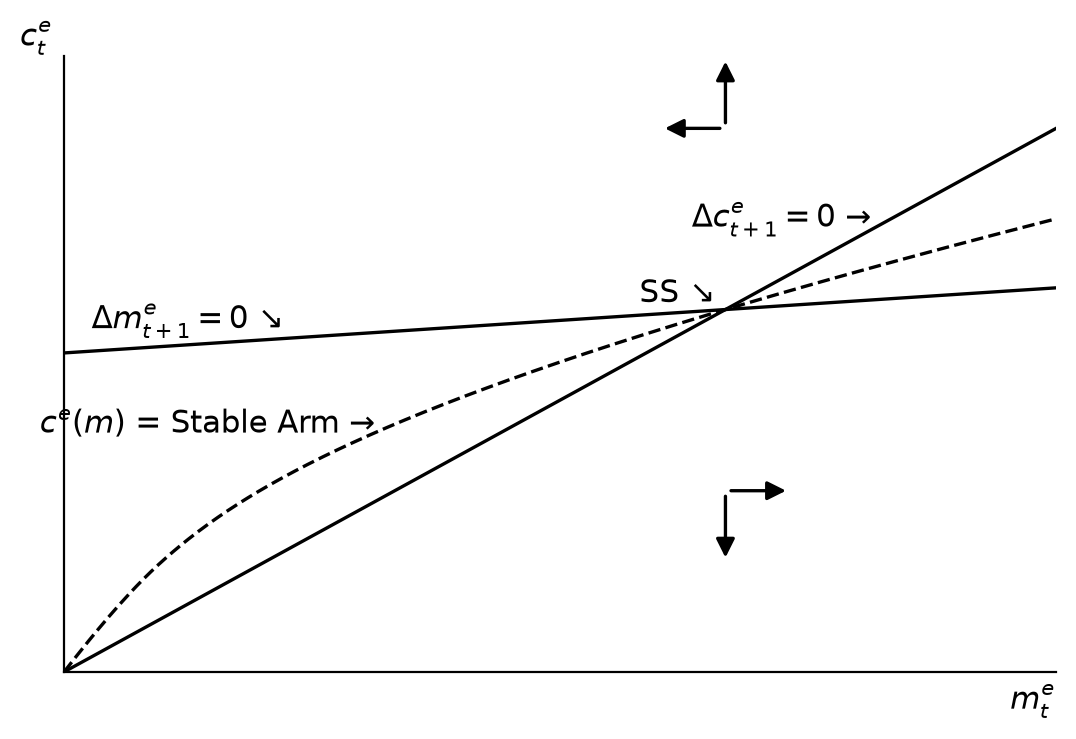

In [ ]:
m_targ, c_targ = base.mTarg, base.cTarg
m_max, c_max = 1.5 * m_targ, 1.7 * c_targ
m = np.linspace(0, m_max, 400)

fig, ax = plt.subplots()
ax.plot(m, base.cSSfunc(m), color="black", linewidth=1.2)
ax.plot(m, base.mSSfunc(m), color="black", linewidth=1.2)
ax.plot(m, c(base, m), color="black", linewidth=1.2, linestyle="--")

m_label = 1.25 * m_targ
ax.text(m_label, base.cSSfunc(m_label), r"$\Delta c^{e}_{t+1} = 0$ →  ", ha="right", va="center")
m_label = m_targ / 3
ax.text(m_label, base.mSSfunc(m_label), r"$\Delta m^{e}_{t+1} = 0$ ↘", ha="right", va="bottom")
m_label = m_targ / 2
ax.text(m_label, c(base, m_label), r"$c^{e}(m)$ = Stable Arm →  ", ha="right", va="center")
ax.text(m_targ, c_targ, "SS ↘ ", ha="right", va="bottom")

arrow = dict(arrowstyle="-|>", color="black", linewidth=1.2, mutation_scale=14)
for (x, y), (dx, dy) in [
    ((m_targ, c_targ / 2), (m_targ / 10, 0)),
    ((m_targ, c_targ / 2), (0, -c_targ / 5)),
    ((m_targ, 1.5 * c_targ), (-m_targ / 10, 0)),
    ((m_targ, 1.5 * c_targ), (0, c_targ / 5)),
]:
    ax.annotate("", xy=(x + dx, y + dy), xytext=(x, y), arrowprops=arrow)

ax.set_xlim(0, m_max)
ax.set_ylim(0, c_max)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel(r"$m^{e}_{t}$", loc="right")
ax.set_ylabel(r"$c^{e}_{t}$", loc="top", rotation=0)
style.save(fig, "PhaseDiag")

## Consumption function

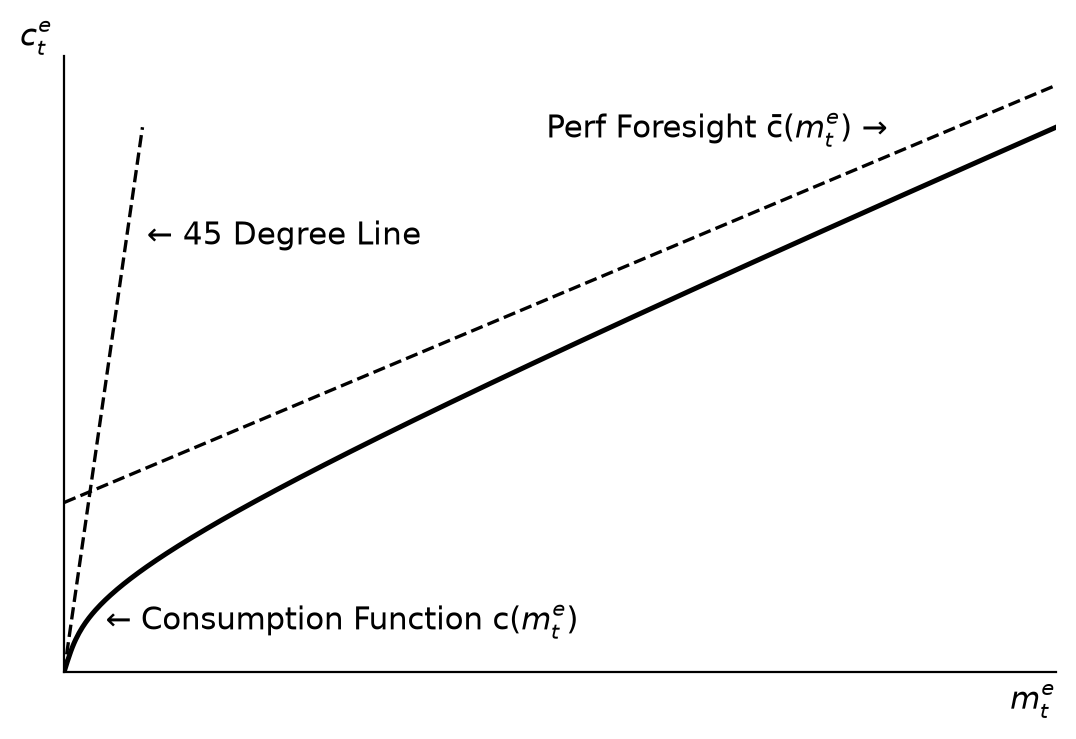

In [ ]:
m_max = 15 * base.mTarg
m = np.linspace(0, m_max, 600)
c_perfect_foresight = (m - 1 + base.h) * base.PFMPC
diagonal = np.linspace(0, c(base, m_max), 100)

fig, ax = plt.subplots()
ax.plot(m, c(base, m), color="black")
ax.plot(m, c_perfect_foresight, color="black", linestyle="--", linewidth=1.2)
ax.plot(diagonal, diagonal, color="black", linestyle="--", linewidth=1.2)

top = c(base, m_max)
ax.text(0.8 * top, 0.8 * top, "  ← 45 Degree Line", ha="left", va="center")
m_label = base.mTarg / 3
label = r"  ← Consumption Function $\mathrm{c}(m^{e}_{t})$"
ax.text(m_label, c(base, m_label), label, ha="left", va="center")
m_label = 0.85 * m_max
ax.text(
    m_label,
    (m_label - 1 + base.h) * base.PFMPC,
    r"Perf Foresight $\bar{\mathrm{c}}(m^{e}_{t})$ →  ",
    ha="right",
    va="bottom",
)

ax.set_xlim(0, m_max)
ax.set_ylim(0, 1.05 * c_perfect_foresight[-1])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel(r"$m^{e}_{t}$", loc="right")
ax.set_ylabel(r"$c^{e}_{t}$", loc="top", rotation=0)
style.save(fig, "cFunc")

## Growth diagrams

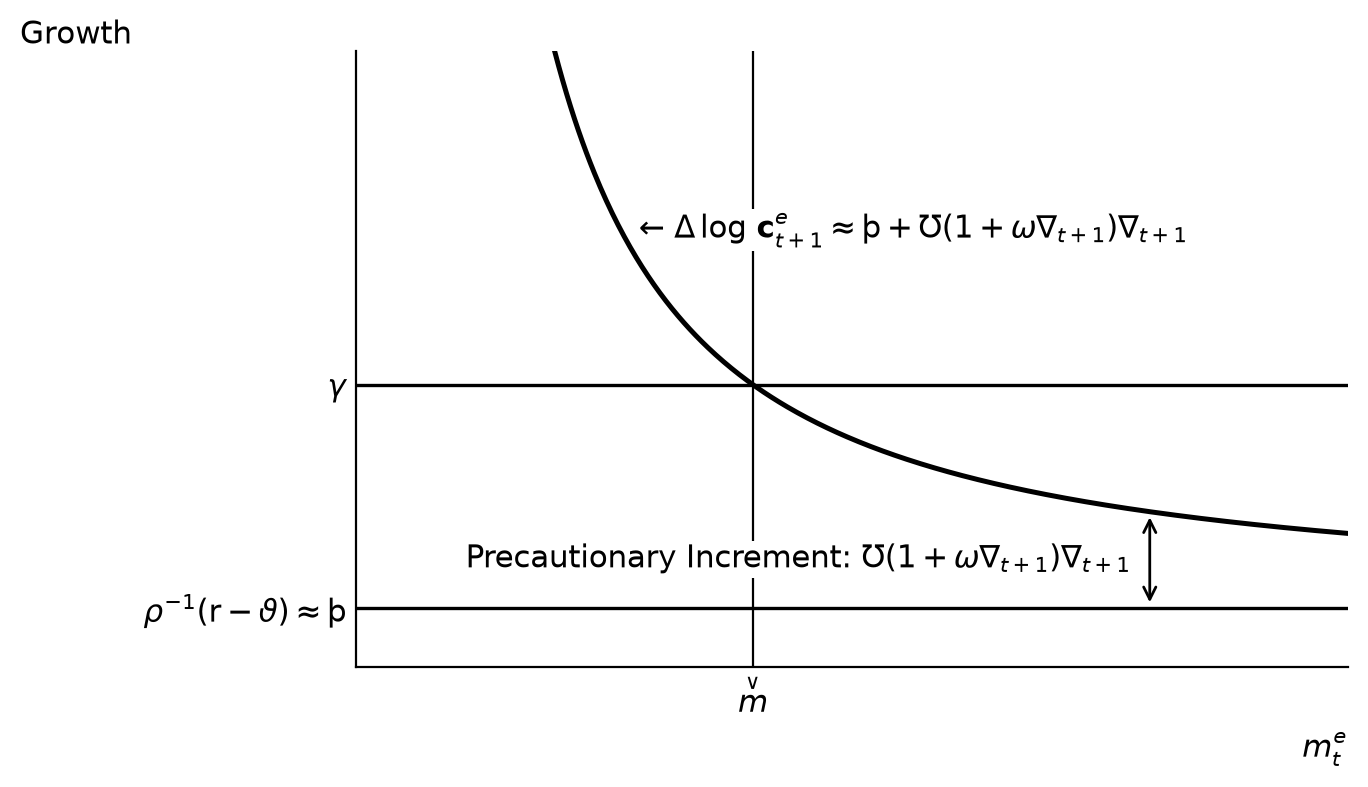

In [ ]:
m_targ = base.mTarg
gamma, thorn = np.log(base.PermGroFacCmp), log_thorn(base)
m = np.linspace(0.5 * m_targ, 2.5 * m_targ, 400)
growth = log_c_growth(base, m)
y_min, y_max = thorn - 0.01, growth[0]

fig, ax = plt.subplots()
ax.plot(m, growth, color="black")
ax.hlines([gamma, thorn], 0, 2.5 * m_targ, color="black", linewidth=1.2)
ax.vlines(m_targ, y_min, y_max, color="black", linewidth=0.8)

unlined = dict(facecolor="white", edgecolor="none", pad=1)  # hides the line behind a label
m_label = 2 * m_targ / 3
ax.text(
    m_label + 0.25,
    log_c_growth(base, m_label),
    r"← $\Delta\,\log\,\mathbf{c}^{e}_{t+1} \approx \mathrm{þ} + \mho(1+\omega\nabla_{t+1})\nabla_{t+1}$",
    ha="left",
    va="center",
    bbox=unlined,
)
m_label = 2 * m_targ
ax.annotate(
    "",
    xy=(m_label, log_c_growth(base, m_label)),
    xytext=(m_label, thorn),
    arrowprops=dict(arrowstyle="<->", color="black", linewidth=1),
)
ax.text(
    m_label - 0.25,
    (log_c_growth(base, m_label) + thorn) / 2,
    r"Precautionary Increment: $\mho(1+\omega\nabla_{t+1})\nabla_{t+1}$",
    ha="right",
    va="center",
    bbox=unlined,
)

ax.set_xlim(0, 2.5 * m_targ)
ax.set_ylim(y_min, y_max)
ax.set_xticks([m_targ], [rf"${M_TARG}$"])
ax.set_yticks([gamma, thorn], [r"$\gamma$", r"$\rho^{-1}(\mathsf{r}-\vartheta) \approx \mathrm{þ}$"])
ax.tick_params(length=0)
ax.set_xlabel(r"$m^{e}_{t}$", loc="right")
ax.set_ylabel("Growth", loc="top", rotation=0)
style.save(fig, "GrowthA")

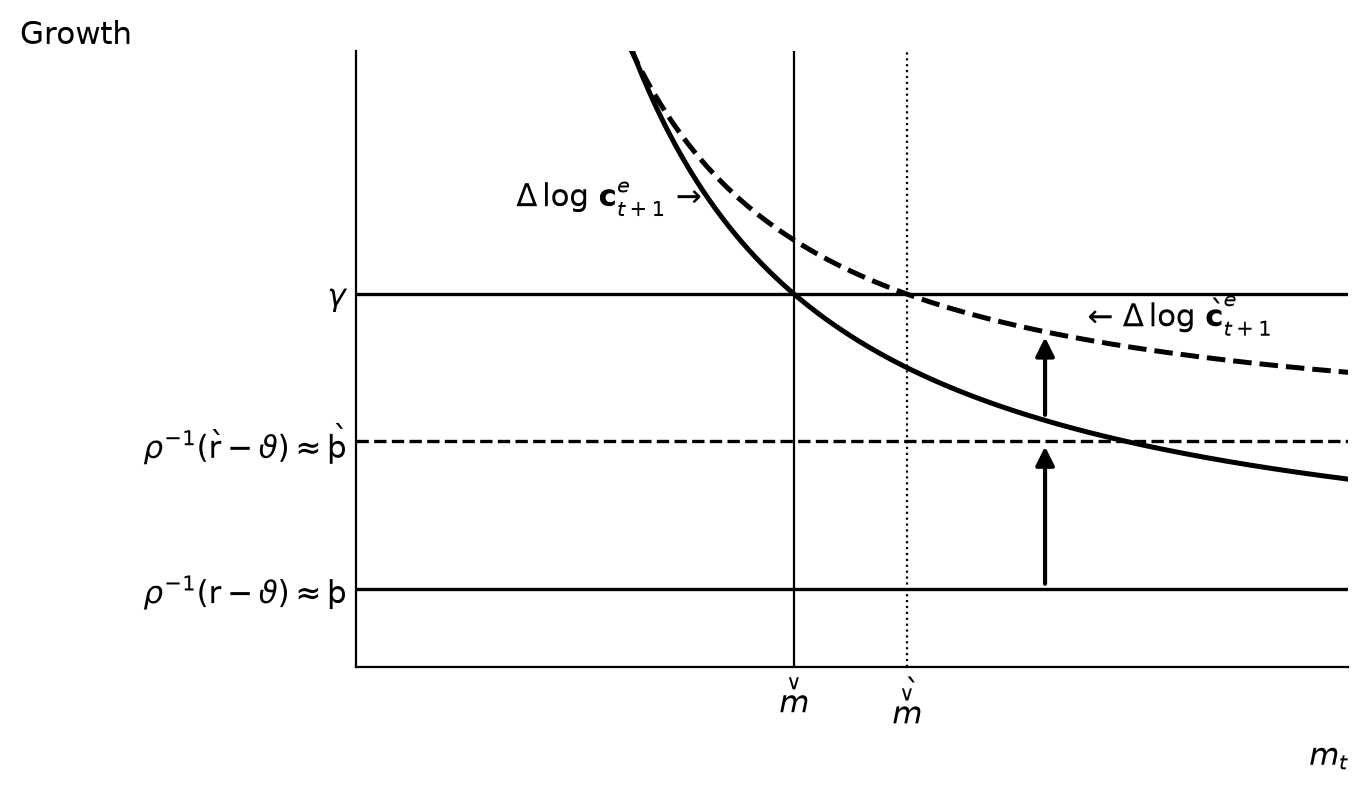

In [ ]:
m_old, m_new = base.mTarg, higher_r.mTarg
gamma = np.log(base.PermGroFacCmp)
thorn_old, thorn_new = log_thorn(base), log_thorn(higher_r)
m = np.linspace(0.5 * m_old, 2.5 * m_old, 400)
y_min, y_max = thorn_old - 0.01, log_c_growth(higher_r, 0.5 * m_new)

fig, ax = plt.subplots()
ax.plot(m, log_c_growth(base, m), color="black")
ax.plot(m, log_c_growth(higher_r, m), color="black", linestyle="--")
ax.hlines([gamma, thorn_old], 0, 2.5 * m_old, color="black", linewidth=1.2)
ax.hlines(thorn_new, 0, 2.5 * m_old, color="black", linewidth=1.2, linestyle="--")
ax.vlines(m_old, y_min, y_max, color="black", linewidth=0.8)
ax.vlines(m_new, y_min, y_max, color="black", linewidth=0.8, linestyle=":")

# The rise in r lifts the perfect foresight growth rate, and with it the whole locus.
arrow = dict(arrowstyle="-|>", color="black", linewidth=1.5, mutation_scale=14)
m_arrow = 1.25 * m_new
ax.annotate("", xy=(m_arrow, thorn_new), xytext=(m_arrow, thorn_old), arrowprops=arrow)
ax.annotate(
    "",
    xy=(m_arrow, log_c_growth(higher_r, m_arrow)),
    xytext=(m_arrow, log_c_growth(base, m_arrow)),
    arrowprops=arrow,
)

m_label = 5 * m_old / 6
label = r"$\Delta\,\log\,\mathbf{c}^{e}_{t+1}$ →  "
ax.text(m_label, log_c_growth(base, m_label), label, ha="right", va="bottom")
m_label = 13 * m_old / 8
ax.text(
    m_label,
    log_c_growth(higher_r, m_label),
    r"  ← $\Delta\,\log\,\grave{\mathbf{c}}^{e}_{t+1}$",
    ha="left",
    va="bottom",
)

ax.set_xlim(0, 1.8 * m_new)
ax.set_ylim(y_min, y_max)
ax.set_xticks([m_old, m_new], [rf"${M_TARG}$", rf"$\grave{{{M_TARG}}}$"])
ax.set_yticks(
    [gamma, thorn_new, thorn_old],
    [
        r"$\gamma$",
        r"$\rho^{-1}(\grave{\mathsf{r}}-\vartheta) \approx \grave{\mathrm{þ}}$",
        r"$\rho^{-1}(\mathsf{r}-\vartheta) \approx \mathrm{þ}$",
    ],
)
ax.tick_params(length=0)
ax.set_xlabel(r"$m_{t}$", loc="right")
ax.set_ylabel("Growth", loc="top", rotation=0)
style.save(fig, "GrowthB")

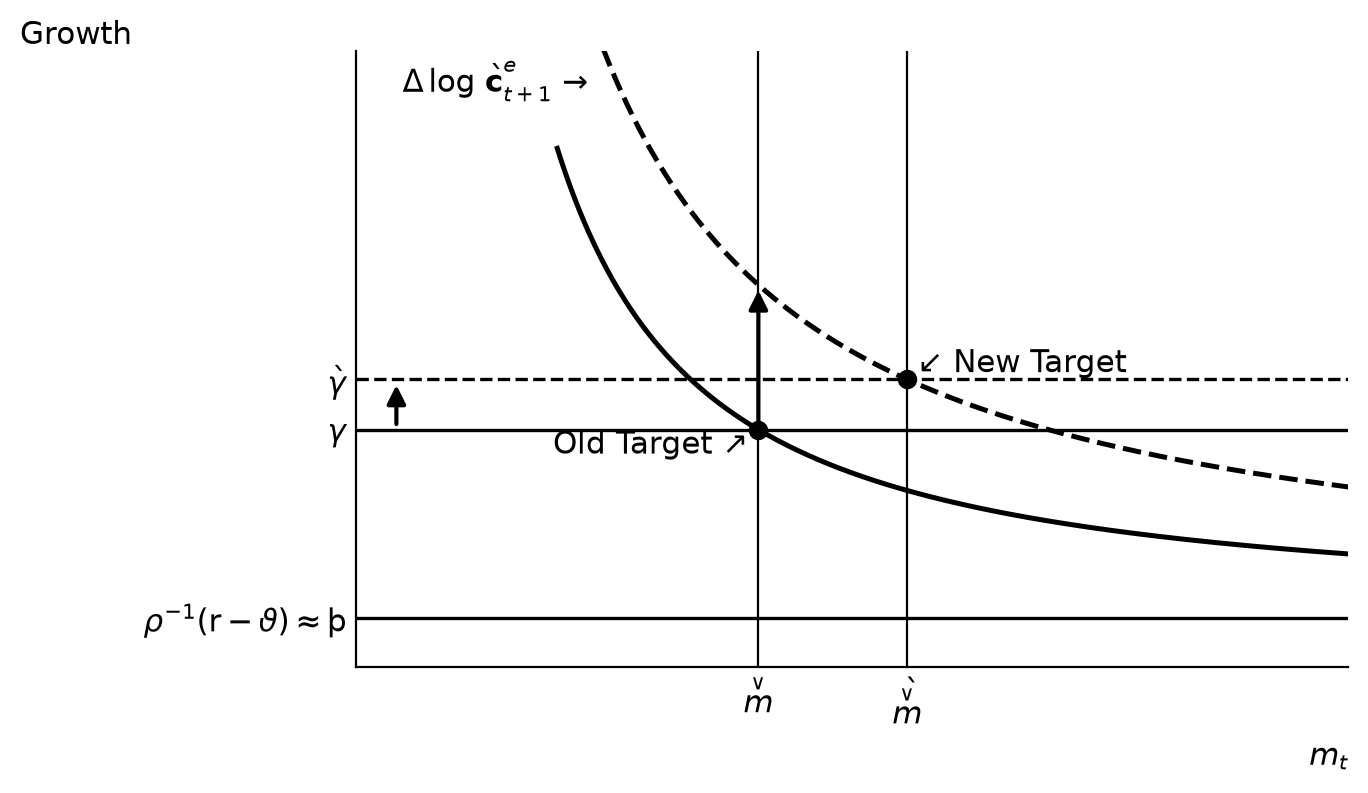

In [ ]:
m_old, m_new = base.mTarg, higher_mho.mTarg
gamma_old, gamma_new = np.log(base.PermGroFacCmp), np.log(higher_mho.PermGroFacCmp)
thorn = log_thorn(base)  # unemployment risk does not change it
m_max = 1.8 * m_new
m = np.linspace(0.5 * m_old, m_max, 400)
y_min, y_max = thorn - 0.01, log_c_growth(higher_mho, 0.45 * m_new)

fig, ax = plt.subplots()
ax.plot(m, log_c_growth(base, m), color="black")
ax.plot(m, log_c_growth(higher_mho, m), color="black", linestyle="--")
ax.hlines([gamma_old, thorn], 0, m_max, color="black", linewidth=1.2)
ax.hlines(gamma_new, 0, m_max, color="black", linewidth=1.2, linestyle="--")
ax.vlines([m_old, m_new], y_min, y_max, color="black", linewidth=0.8)
ax.plot([m_old, m_new], [gamma_old, gamma_new], "o", color="black", markersize=6)
ax.text(m_old, gamma_old, "Old Target ↗ ", ha="right", va="top")
ax.text(m_new, gamma_new, " ↙ New Target", ha="left", va="bottom")

arrow = dict(arrowstyle="-|>", color="black", linewidth=1.5, mutation_scale=14)
ax.annotate("", xy=(0.1 * m_old, gamma_new), xytext=(0.1 * m_old, gamma_old), arrowprops=arrow)
ax.annotate(
    "", xy=(m_old, log_c_growth(higher_mho, m_old)), xytext=(m_old, gamma_old), arrowprops=arrow
)

m_label = 7.5 * m_old / 12
ax.text(
    m_label,
    log_c_growth(higher_mho, m_label),
    r"$\Delta\,\log\,\grave{\mathbf{c}}^{e}_{t+1}$ →  ",
    ha="right",
    va="top",
)

ax.set_xlim(0, m_max)
ax.set_ylim(y_min, y_max)
ax.set_xticks([m_old, m_new], [rf"${M_TARG}$", rf"$\grave{{{M_TARG}}}$"])
ax.set_yticks(
    [gamma_new, gamma_old, thorn],
    [r"$\grave{\gamma}$", r"$\gamma$", r"$\rho^{-1}(\mathsf{r}-\vartheta) \approx \mathrm{þ}$"],
)
ax.tick_params(length=0)
ax.set_xlabel(r"$m_{t}$", loc="right")
ax.set_ylabel("Growth", loc="top", rotation=0)
style.save(fig, "cGroIncreaseMhoPlot")

## A fall in the time preference rate

The consumer starts at the benchmark target and, from period 0 on, has the time preference
rate 0.08. The consumer stays employed throughout.

In [ ]:
BEFORE, AFTER = 4, 75  # periods shown before and from period 0
m_after, c_after = path(patient, base.mTarg, AFTER)
periods = np.arange(-BEFORE, AFTER)

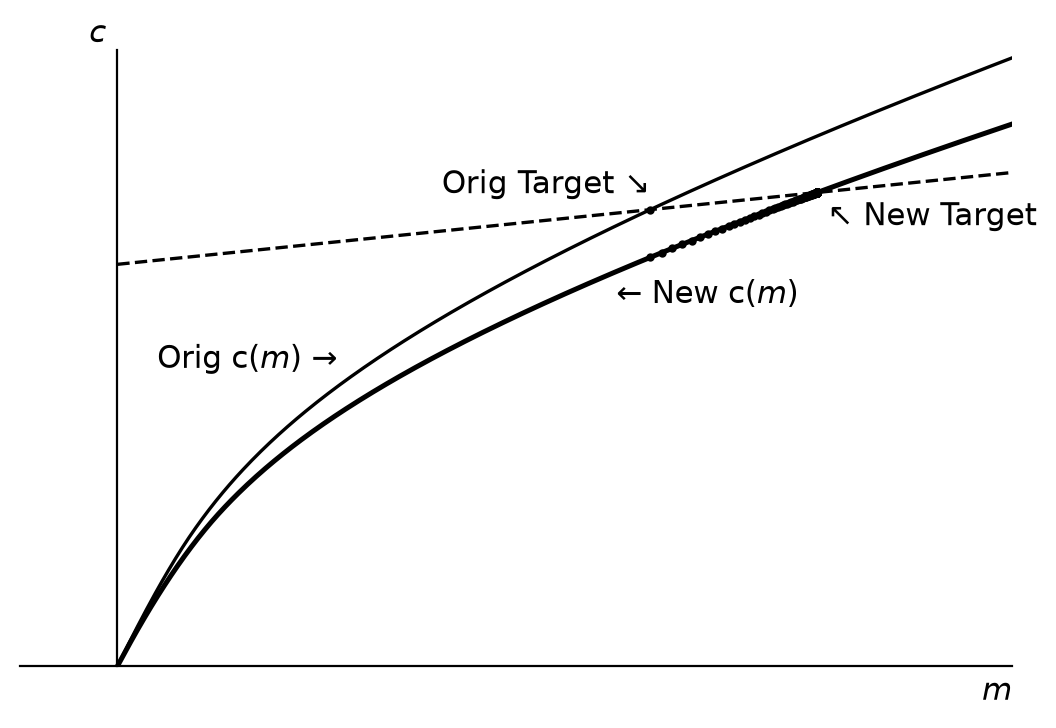

In [ ]:
m_old, c_old = base.mTarg, base.cTarg
m_new, c_new = patient.mTarg, patient.cTarg
m = np.linspace(0, m_new + 2, 400)
m_dots, c_dots = path(patient, m_old, 200)

fig, ax = plt.subplots()
ax.plot(m, c(base, m), color="black", linewidth=1.2)
ax.plot(m, c(patient, m), color="black")
ax.plot(m, base.mSSfunc(m), color="black", linewidth=1.2, linestyle="--")
ax.plot(np.r_[m_old, m_dots], np.r_[c_old, c_dots], ".", color="black", markersize=4)

ax.text(m_old, 1.02 * c_old, "Orig Target ↘", ha="right", va="bottom")
ax.text(m_new, 0.98 * c_new, " ↖ New Target", ha="left", va="top")
ax.text(0.45 * m_old, 0.67 * c_old, r"Orig c($m$) →  ", ha="right", va="center")
ax.text(0.9 * m_old, c(patient, 0.9 * m_old), r"  ← New c($m$)", ha="left", va="top")

ax.spines["left"].set_position(("data", 0))
ax.set_xlim(-1, m_new + 2)
ax.set_ylim(0, 1.3 * c_new)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel(r"$m$", loc="right")
ax.set_ylabel(r"$c$", loc="top", rotation=0)
style.save(fig, "DecreaseTheta")

In [ ]:
def time_path_axes(ax, series, ylabel):
    """A path figure in the handout's style: dots, time ticks, no ticks on the value axis."""
    ax.plot(periods[: len(series)], series, ".", color="black", markersize=6)
    ax.set_xlim(periods[0] - 2, periods[-1] + 2)
    ax.set_ylim(0, 1.05 * np.max(series))
    ax.set_xticks([0, 25, 50, 75])
    ax.set_yticks([])
    ax.set_xlabel("Time", loc="right")
    ax.set_ylabel(ylabel, loc="top", rotation=0)

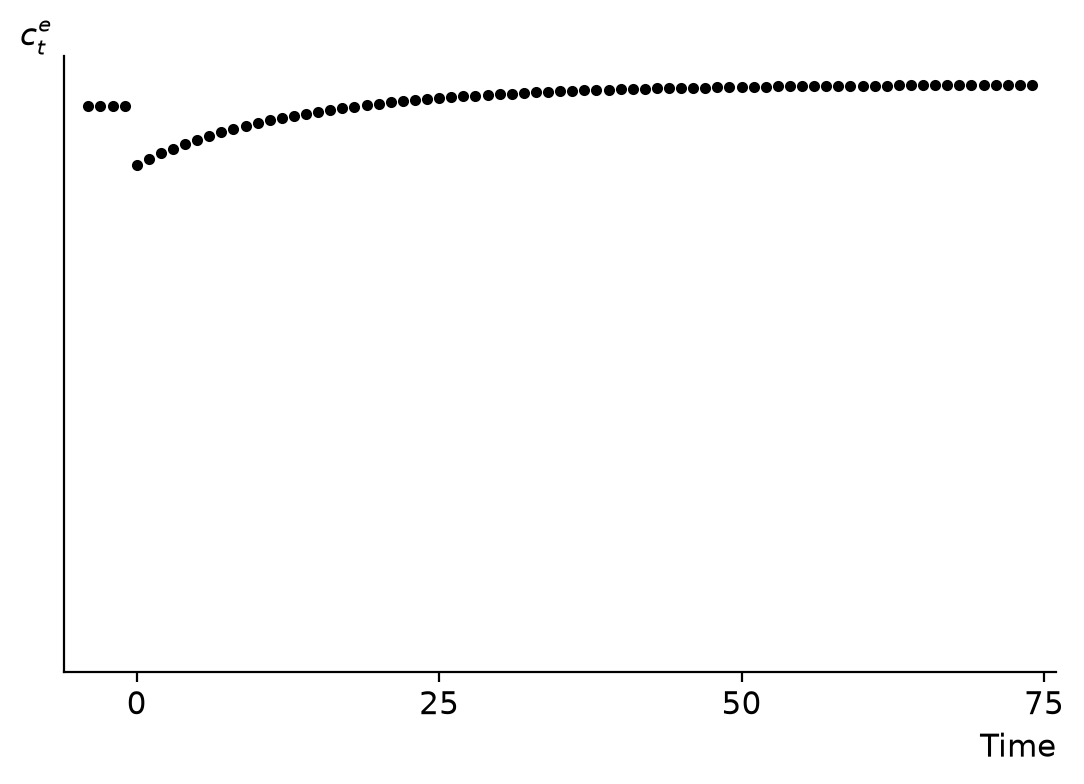

In [ ]:
fig, ax = plt.subplots()
time_path_axes(ax, np.r_[np.full(BEFORE, base.cTarg), c_after], r"$c^{e}_{t}$")
style.save(fig, "cPathAfterThetaDrop")

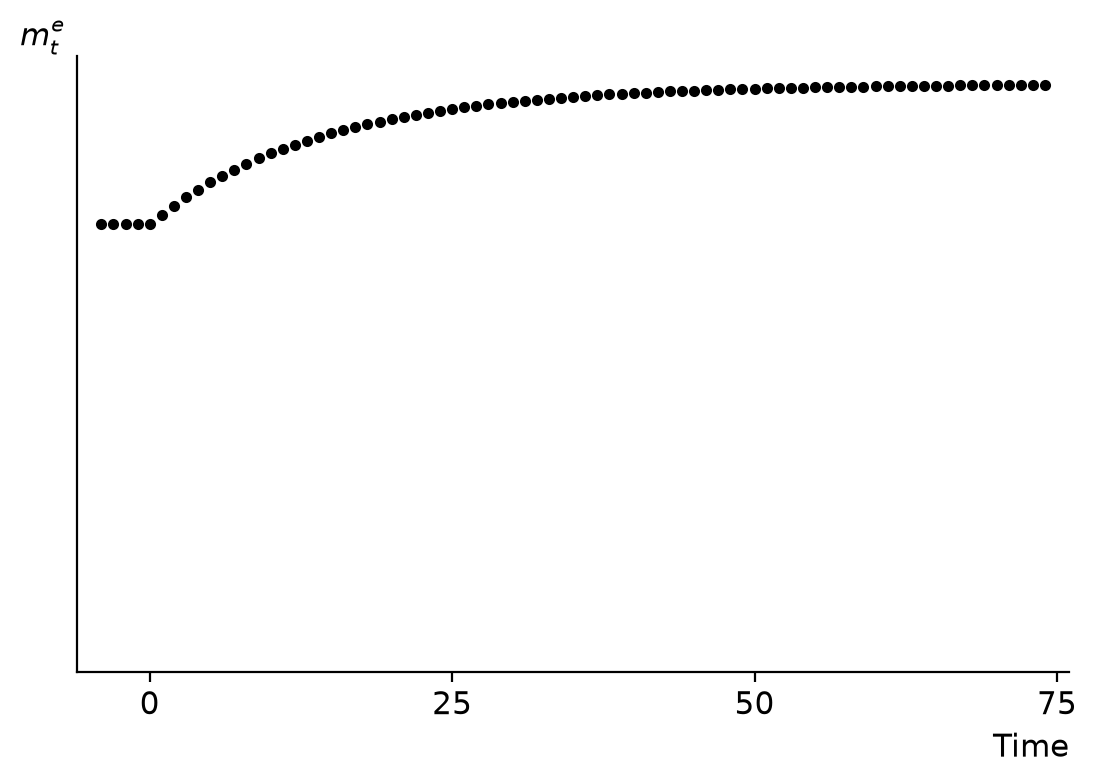

In [ ]:
fig, ax = plt.subplots()
time_path_axes(ax, np.r_[np.full(BEFORE, base.mTarg), m_after], r"$m^{e}_{t}$")
style.save(fig, "mPathAfterThetaDrop")

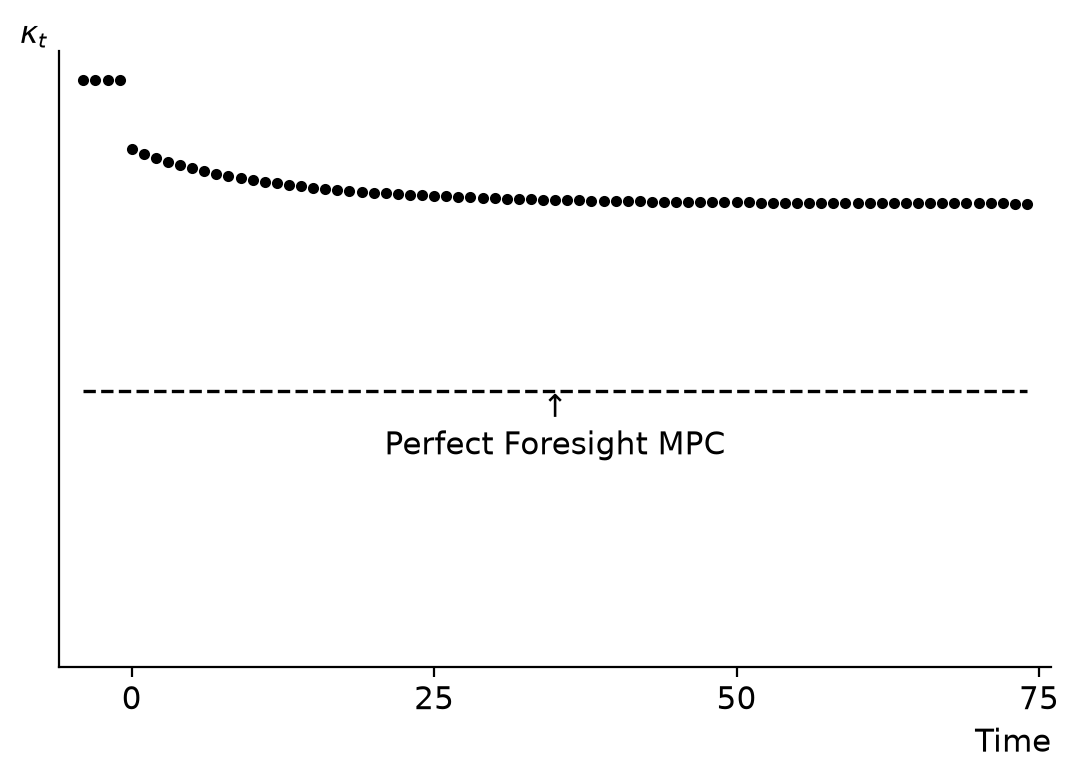

In [ ]:
fig, ax = plt.subplots()
time_path_axes(ax, np.r_[np.full(BEFORE, base.MPCtarg), mpc(patient, m_after)], r"$\kappa_{t}$")
ax.hlines(patient.PFMPC, periods[0], periods[-1], color="black", linewidth=1.2, linestyle="--")
middle = (periods[0] + periods[-1]) / 2
ax.text(middle, patient.PFMPC, "↑\nPerfect Foresight MPC", ha="center", va="top")
style.save(fig, "MPCPathAfterThetaDrop")

## The small open economy

Aggregate consumption is the labor-income-weighted average of cohorts' consumption ratios. The
cohort born $j$ periods ago earns $\EmpGro^{-j}$ times the newborns' labor income
[eq:TBS-LabIncTot](#eq:TBS-LabIncTot). So the cohorts at least $k$ periods old together earn a fraction
$\EmpGro^{-k}$ of all labor income.

With stakes, every household is at the benchmark target before period 0. From period 0,
newborns receive the new target stake, so they start at the new target and stay there. The
households born before period 0 follow the individual's path from the old target. At date
$t$ they are at least $t+1$ periods old, so their income weight is
$\EmpGro^{-(t+1)}$.

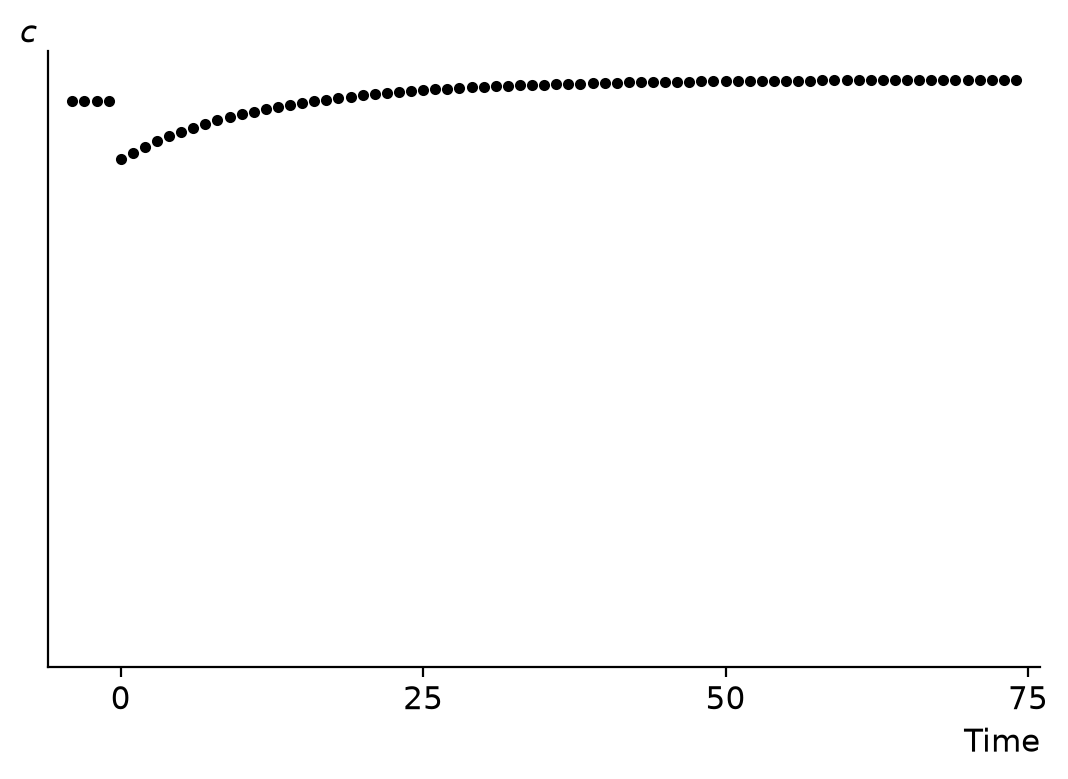

In [ ]:
survivor_weight = POP_GROWTH ** -(np.arange(AFTER) + 1.0)
c_aggregate = survivor_weight * c_after + (1 - survivor_weight) * patient.cTarg

fig, ax = plt.subplots()
time_path_axes(ax, np.r_[np.full(BEFORE, base.cTarg), c_aggregate], r"$c$")
style.save(fig, "SOEStakescPathAfterThetaDropPlot")

Without stakes, saving was impossible before period 0, so every household starts period 0
with $\mRat = 1$. A household that has been able to save for $s$ periods has the
individual's $s$-th value on a path starting from $\mRat = 1$. At date $t$,
every household born in or before period 0 has saved for $t$ periods. These households
are at least $t$ periods old, so their income weight is $\EmpGro^{-t}$. A
household born $j < t$ periods ago has saved for $j$ periods.

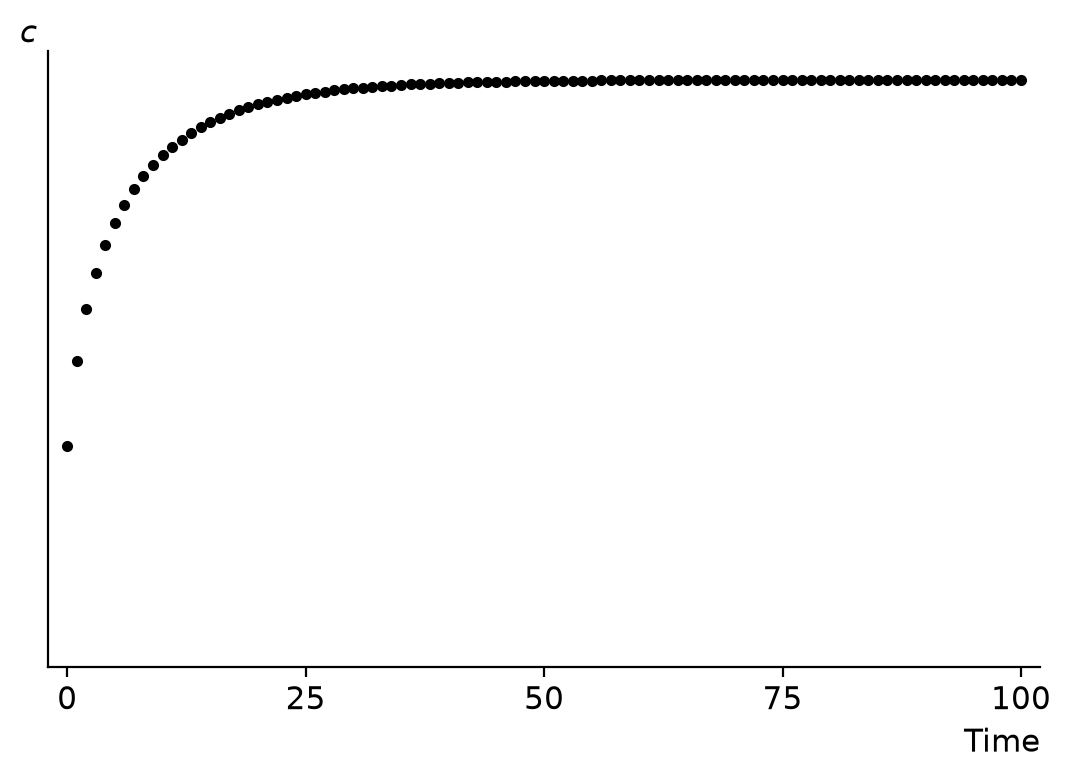

In [ ]:
horizon = 101
m_saving, c_saving = path(base, 1.0, horizon)
t = np.arange(horizon)
weight = POP_GROWTH ** -t.astype(float)
# Households born in or before period 0 have saved for t periods: income share weight[t].
# Those born j < t periods ago have saved for j: income share (1 - 1/POP_GROWTH) weight[j].
younger = np.r_[0.0, np.cumsum(weight[:-1] * c_saving[:-1])]
c_aggregate = weight * c_saving + (1 - 1 / POP_GROWTH) * younger

fig, ax = plt.subplots()
ax.plot(t, c_aggregate, ".", color="black", markersize=6)
ax.set_xlim(-2, horizon + 1)
ax.set_ylim(0, 1.05 * c_aggregate.max())
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_yticks([])
ax.set_xlabel("Time", loc="right")
ax.set_ylabel(r"$c$", loc="top", rotation=0)
style.save(fig, "SOENoStakescPath")